# Basics

## Read, count, and reverse complement

In [1]:
# Read genomic data
def readGenome(filename):
    genome = ''
    with open(filename, 'r') as f:
        for line in f:
            if not line[0] == '>':
                genome += line.rstrip()
    return genome

lambda_virus_genome = readGenome('lambda_virus.txt')
print(lambda_virus_genome[:20])

GGGCGGCGACCTCGCGGGTT


In [2]:
# Number of bases in the strand
def count(genome):
    counts = {'A': 0, 'C': 0, 'G': 0, 'T': 0}
    for base in genome:
        counts[base] += 1
    print(counts)

count(lambda_virus_genome)

{'A': 12334, 'C': 11362, 'G': 12820, 'T': 11986}


In [3]:
# Get the antisense strand
def reverseComplement(senseStrand):
    complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C', 'N': 'N'}
    antisenseStrand = ''
    for base in senseStrand:
        antisenseStrand = complement[base] + antisenseStrand
    return antisenseStrand

lambda_virus_genomeAntisense = reverseComplement(lambda_virus_genome)
print(lambda_virus_genomeAntisense[:20])

CGTAACCTGTCGGATCACCG


## Quality scores

In [4]:
# Read genome reads (sequences and quality values)
def readReads(filename):
    sequences = []
    qualities = []
    with open(filename, 'r') as f:
        while True:
            f.readline()
            seq = f.readline().rstrip()
            f.readline()
            qual = f.readline().rstrip()
            if len(seq) == 0:
                break
            sequences.append(seq)
            qualities.append(qual)
    return sequences, qualities

human_seqs, human_quals = readReads('SRR835775_1.first1000.txt')
print(human_seqs[1])
print(human_quals[1])

TAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACC
CCCFFFFFGHHGHJJJJJIJGIIJJJJJJJIJIJJJJJFJJFGIIIIH=CBFCF=CCEG)=>EHB2@@DEC>;;?=;(=?BBD?59?BA###########


In [5]:
# Convert quality values to numbers
def phred33ToQ(qual):
    return ord(qual) - 33

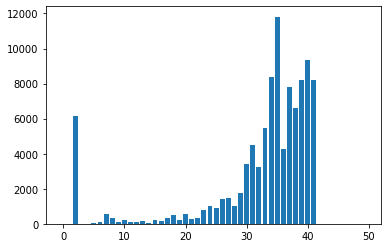

In [6]:
# Create a histogram of the frequency of qualities
import matplotlib.pyplot as plt
%matplotlib inline
def createHist(qualities):
    hist = [0] * 50
    for qual in qualities:
        for phred in qual:
            q = phred33ToQ(phred)
            hist[q] += 1
    return hist
h = createHist(human_quals)
plt.bar(range(len(h)), h)
plt.show()

## Find GCs

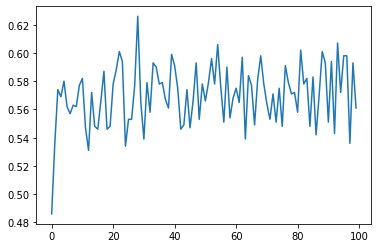

In [7]:
# Find GCs by position
def findGCByPos(reads):
    gc = [0] * 100
    totals = [0] * 100
    for read in reads:
        for base in range(len(read)):
            if read[base] == 'C' or read[base] == 'G':
                gc[base] += 1
            totals[base] += 1
    for i in range(len(gc)):
        if totals[i] > 0:
            gc[i] /= float(totals[i])
    return gc

gc = findGCByPos(human_seqs)
plt.plot(range(len(gc)), gc)
plt.show()

# Read alignment problem, Exact matching

<img src="Exact matching.png" width="500">

## Naive exact matching

In [8]:
# Read genomic data
def readGenome(filename):
    genome = ''
    with open(filename, 'r') as f:
        for line in f:
            if not line[0] == '>':
                genome += line.rstrip()
    return genome

phix_genome = readGenome('phi_x.txt')
print(phix_genome[:20])

GAGTTTTATCGCTTCCATGA


In [9]:
# Naive exact matching
def naive(p, t):
    occurrences = []
    for i in range(len(t) - len(p) + 1):
        match = True
        for j in range(len(p)):
            if not t[i+j] == p[j]:
                match = False
                break
        if match:
            occurrences.append(i)
    return occurrences

occur = naive('AGCG', phix_genome)
print(occur)

[334, 723, 917, 1025, 1410, 1640, 2315, 2356, 2361, 3324, 3735, 4032, 4524, 4808]


In [10]:
# Generate random artificial reads from a genome
import random
def generateReads(genome, numReads, readLn):
    reads = []
    for _ in range(numReads):
        start = random.randint(0, len(genome)-readLn) - 1
        reads.append(genome[start : start+readLn])
    return reads

phix_art_seqs = generateReads(phix_genome, 100, 100)

In [11]:
# Check how many of reads match the genome
def numMatched(reads, genome):
    numMatched = 0
    for read in reads:
        mtaches = naive(read, genome)
        if len(mtaches) > 0:
            numMatched += 1
    print(f'{numMatched} / {len(reads)} reads matched the genome exactly.')

numMatched(phix_art_seqs, phix_genome)

100 / 100 reads matched the genome exactly.


In [12]:
# Read real reads from Phi X genome
def readReads(filename):
    sequences = []
    qualities = []
    with open(filename, 'r') as f:
        while True:
            f.readline()
            seq = f.readline().rstrip()
            f.readline()
            qual = f.readline().rstrip()
            if len(seq) == 0:
                break
            sequences.append(seq)
            qualities.append(qual)
    return sequences, qualities

phix_seqs, phix_quals = readReads('ERR266411_1.first1000.txt')
print(phix_seqs[1])
print(phix_quals[1])

AACAAGCAGTAGTAATTCCTGCTTTATCAAGATAATTTTTCGACTCATCAGAAATATACGAAAGTGTTAACTTCTGCGTCATGGACACGAAAAAACTCCC
=@@CEBF@BGBG6GF1E<04C3E7E.9G=H<H:HH;HBH;G69F7,7DG((EG8A8,-5-8,?,,,AE>C,B?,,,64$AC'+'='+4'3*4+E322*'(


In [13]:
numMatched(phix_seqs, phix_genome)

7 / 1000 reads matched the genome exactly.


In [14]:
# Check how many of the first 30 bases in each read match the genome
def numMatched30(reads, genome):
    numMatched = 0
    for read in reads:
        read = read[:30]
        matches = naive(read, genome)
        if len(matches) > 0:
            numMatched += 1
    print(f'{numMatched} / {len(reads)} reads matched the genome exactly in their initial 30 bases.')

numMatched30(phix_seqs, phix_genome)

459 / 1000 reads matched the genome exactly in their initial 30 bases.


In [15]:
# Check the exact matches in the antisense strand as well
def numMatched30BothStrands(reads, genome):
    numMatched = 0
    for read in reads:
        read = read[:30]
        matches = naive(read, genome)
        matches.extend(naive(reverseComplement(read), genome))
        if len(matches) > 0:
            numMatched += 1
    print(f'{numMatched} / {len(reads)} reads matched the genome exactly in their initial 30 bases.')

numMatched30BothStrands(phix_seqs, phix_genome)

932 / 1000 reads matched the genome exactly in their initial 30 bases.


## Boyer Moore exact matching

In [16]:
import string

def z_array(s):
    """ Use Z algorithm (Gusfield theorem 1.4.1) to preprocess s """
    assert len(s) > 1
    z = [len(s)] + [0] * (len(s)-1)
    # Initial comparison of s[1:] with prefix
    for i in range(1, len(s)):
        if s[i] == s[i-1]:
            z[1] += 1
        else:
            break
    r, l = 0, 0
    if z[1] > 0:
        r, l = z[1], 1
    for k in range(2, len(s)):
        assert z[k] == 0
        if k > r:
            # Case 1
            for i in range(k, len(s)):
                if s[i] == s[i-k]:
                    z[k] += 1
                else:
                    break
            r, l = k + z[k] - 1, k
        else:
            # Case 2
            # Calculate length of beta
            nbeta = r - k + 1
            zkp = z[k - l]
            if nbeta > zkp:
                # Case 2a: Zkp wins
                z[k] = zkp
            else:
                # Case 2b: Compare characters just past r
                nmatch = 0
                for i in range(r+1, len(s)):
                    if s[i] == s[i - k]:
                        nmatch += 1
                    else:
                        break
                l, r = k, r + nmatch
                z[k] = r - k + 1
    return z


def n_array(s):
    """ Compile the N array (Gusfield theorem 2.2.2) from the Z array """
    return z_array(s[::-1])[::-1]


def big_l_prime_array(p, n):
    """ Compile L' array (Gusfield theorem 2.2.2) using p and N array.
        L'[i] = largest index j less than n such that N[j] = |P[i:]| """
    lp = [0] * len(p)
    for j in range(len(p)-1):
        i = len(p) - n[j]
        if i < len(p):
            lp[i] = j + 1
    return lp


def big_l_array(p, lp):
    """ Compile L array (Gusfield theorem 2.2.2) using p and L' array.
        L[i] = largest index j less than n such that N[j] >= |P[i:]| """
    l = [0] * len(p)
    l[1] = lp[1]
    for i in range(2, len(p)):
        l[i] = max(l[i-1], lp[i])
    return l


def small_l_prime_array(n):
    """ Compile lp' array (Gusfield theorem 2.2.4) using N array. """
    small_lp = [0] * len(n)
    for i in range(len(n)):
        if n[i] == i+1:  # prefix matching a suffix
            small_lp[len(n)-i-1] = i+1
    for i in range(len(n)-2, -1, -1):  # "smear" them out to the left
        if small_lp[i] == 0:
            small_lp[i] = small_lp[i+1]
    return small_lp


def good_suffix_table(p):
    """ Return tables needed to apply good suffix rule. """
    n = n_array(p)
    lp = big_l_prime_array(p, n)
    return lp, big_l_array(p, lp), small_l_prime_array(n)


def good_suffix_mismatch(i, big_l_prime, small_l_prime):
    """ Given a mismatch at offset i, and given L/L' and l' arrays,
        return amount to shift as determined by good suffix rule. """
    length = len(big_l_prime)
    assert i < length
    if i == length - 1:
        return 0
    i += 1  # i points to leftmost matching position of P
    if big_l_prime[i] > 0:
        return length - big_l_prime[i]
    return length - small_l_prime[i]


def good_suffix_match(small_l_prime):
    """ Given a full match of P to T, return amount to shift as
        determined by good suffix rule. """
    return len(small_l_prime) - small_l_prime[1]


def dense_bad_char_tab(p, amap):
    """ Given pattern string and list with ordered alphabet characters, create
        and return a dense bad character table.  Table is indexed by offset
        then by character. """
    tab = []
    nxt = [0] * len(amap)
    for i in range(0, len(p)):
        c = p[i]
        assert c in amap
        tab.append(nxt[:])
        nxt[amap[c]] = i+1
    return tab


class BoyerMoore(object):
    """ Encapsulates pattern and associated Boyer-Moore preprocessing. """
    
    def __init__(self, p, alphabet='ACGT'):
        self.p = p
        self.alphabet = alphabet
        # Create map from alphabet characters to integers
        self.amap = {}
        for i in range(len(self.alphabet)):
            self.amap[self.alphabet[i]] = i
        # Make bad character rule table
        self.bad_char = dense_bad_char_tab(p, self.amap)
        # Create good suffix rule table
        _, self.big_l, self.small_l_prime = good_suffix_table(p)
    
    def bad_character_rule(self, i, c):
        """ Return # skips given by bad character rule at offset i """
        assert c in self.amap
        ci = self.amap[c]
        assert i > (self.bad_char[i][ci]-1)
        return i - (self.bad_char[i][ci]-1)
    
    def good_suffix_rule(self, i):
        """ Given a mismatch at offset i, return amount to shift
            as determined by (weak) good suffix rule. """
        length = len(self.big_l)
        assert i < length
        if i == length - 1:
            return 0
        i += 1  # i points to leftmost matching position of P
        if self.big_l[i] > 0:
            return length - self.big_l[i]
        return length - self.small_l_prime[i]
    
    def match_skip(self):
        """ Return amount to shift in case where P matches T """
        return len(self.small_l_prime) - self.small_l_prime[1]

def boyer_moore(p, p_bm, t):
    """ Do Boyer-Moore matching """
    i = 0
    occurrences = []
    while i < len(t) - len(p) + 1:
        shift = 1
        mismatched = False
        for j in range(len(p)-1, -1, -1):
            if p[j] != t[i+j]:
                skip_bc = p_bm.bad_character_rule(j, t[i+j])
                skip_gs = p_bm.good_suffix_rule(j)
                shift = max(shift, skip_bc, skip_gs)
                mismatched = True
                break
        if not mismatched:
            occurrences.append(i)
            skip_gs = p_bm.match_skip()
            shift = max(shift, skip_gs)
        i += shift
    return occurrences

In [17]:
t = 'GCTAGCTCTACGAGTCTA'
p = 'TCTA'
p_bm = BoyerMoore(p, alphabet='ACGT') # Preprocessing
boyer_moore(p, p_bm, t) # Boyer Moore function

[6, 14]

## k-mer indexing

In [18]:
import bisect
class Index(object):
    def __init__(self, t, k):
        self.k = k
        self.index = []
        for i in range(len(t) - k + 1):
            self.index.append((t[i:i+k], i))
        self.index.sort()
    
    def query(self, p):
        kmer = p[:self.k]
        i = bisect.bisect_left(self.index, (kmer, -1))
        hits = []
        while i < len(self.index):
            if self.index[i][0] != kmer:
                break
            hits.append(self.index[i][1])
            i += 1
        return hits

def queryIndex(p, t, index):
    k = index.k
    offsets = []
    for i in index.query(p):
        if p[k:] == t[i+k:i+len(p)]:
            offsets.append(i)
    print(offsets)

In [19]:
# Test
t = 'GCTAGCTCTACGAGTCTA'
p = 'TCTA'

index = Index(t, 2)
queryIndex(p, t, index)

[6, 14]


# Read alignment problem, Approximate matching

## Boyer Moore + Pigenhole principle

In [20]:
# Booyer Moore exact matching
import string

def z_array(s):
    """ Use Z algorithm (Gusfield theorem 1.4.1) to preprocess s """
    assert len(s) > 1
    z = [len(s)] + [0] * (len(s)-1)
    # Initial comparison of s[1:] with prefix
    for i in range(1, len(s)):
        if s[i] == s[i-1]:
            z[1] += 1
        else:
            break
    r, l = 0, 0
    if z[1] > 0:
        r, l = z[1], 1
    for k in range(2, len(s)):
        assert z[k] == 0
        if k > r:
            # Case 1
            for i in range(k, len(s)):
                if s[i] == s[i-k]:
                    z[k] += 1
                else:
                    break
            r, l = k + z[k] - 1, k
        else:
            # Case 2
            # Calculate length of beta
            nbeta = r - k + 1
            zkp = z[k - l]
            if nbeta > zkp:
                # Case 2a: Zkp wins
                z[k] = zkp
            else:
                # Case 2b: Compare characters just past r
                nmatch = 0
                for i in range(r+1, len(s)):
                    if s[i] == s[i - k]:
                        nmatch += 1
                    else:
                        break
                l, r = k, r + nmatch
                z[k] = r - k + 1
    return z


def n_array(s):
    """ Compile the N array (Gusfield theorem 2.2.2) from the Z array """
    return z_array(s[::-1])[::-1]


def big_l_prime_array(p, n):
    """ Compile L' array (Gusfield theorem 2.2.2) using p and N array.
        L'[i] = largest index j less than n such that N[j] = |P[i:]| """
    lp = [0] * len(p)
    for j in range(len(p)-1):
        i = len(p) - n[j]
        if i < len(p):
            lp[i] = j + 1
    return lp


def big_l_array(p, lp):
    """ Compile L array (Gusfield theorem 2.2.2) using p and L' array.
        L[i] = largest index j less than n such that N[j] >= |P[i:]| """
    l = [0] * len(p)
    l[1] = lp[1]
    for i in range(2, len(p)):
        l[i] = max(l[i-1], lp[i])
    return l


def small_l_prime_array(n):
    """ Compile lp' array (Gusfield theorem 2.2.4) using N array. """
    small_lp = [0] * len(n)
    for i in range(len(n)):
        if n[i] == i+1:  # prefix matching a suffix
            small_lp[len(n)-i-1] = i+1
    for i in range(len(n)-2, -1, -1):  # "smear" them out to the left
        if small_lp[i] == 0:
            small_lp[i] = small_lp[i+1]
    return small_lp


def good_suffix_table(p):
    """ Return tables needed to apply good suffix rule. """
    n = n_array(p)
    lp = big_l_prime_array(p, n)
    return lp, big_l_array(p, lp), small_l_prime_array(n)


def good_suffix_mismatch(i, big_l_prime, small_l_prime):
    """ Given a mismatch at offset i, and given L/L' and l' arrays,
        return amount to shift as determined by good suffix rule. """
    length = len(big_l_prime)
    assert i < length
    if i == length - 1:
        return 0
    i += 1  # i points to leftmost matching position of P
    if big_l_prime[i] > 0:
        return length - big_l_prime[i]
    return length - small_l_prime[i]


def good_suffix_match(small_l_prime):
    """ Given a full match of P to T, return amount to shift as
        determined by good suffix rule. """
    return len(small_l_prime) - small_l_prime[1]


def dense_bad_char_tab(p, amap):
    """ Given pattern string and list with ordered alphabet characters, create
        and return a dense bad character table.  Table is indexed by offset
        then by character. """
    tab = []
    nxt = [0] * len(amap)
    for i in range(0, len(p)):
        c = p[i]
        assert c in amap
        tab.append(nxt[:])
        nxt[amap[c]] = i+1
    return tab


class BoyerMoore(object):
    """ Encapsulates pattern and associated Boyer-Moore preprocessing. """
    
    def __init__(self, p, alphabet='ACGT'):
        self.p = p
        self.alphabet = alphabet
        # Create map from alphabet characters to integers
        self.amap = {}
        for i in range(len(self.alphabet)):
            self.amap[self.alphabet[i]] = i
        # Make bad character rule table
        self.bad_char = dense_bad_char_tab(p, self.amap)
        # Create good suffix rule table
        _, self.big_l, self.small_l_prime = good_suffix_table(p)
    
    def bad_character_rule(self, i, c):
        """ Return # skips given by bad character rule at offset i """
        assert c in self.amap
        ci = self.amap[c]
        assert i > (self.bad_char[i][ci]-1)
        return i - (self.bad_char[i][ci]-1)
    
    def good_suffix_rule(self, i):
        """ Given a mismatch at offset i, return amount to shift
            as determined by (weak) good suffix rule. """
        length = len(self.big_l)
        assert i < length
        if i == length - 1:
            return 0
        i += 1  # i points to leftmost matching position of P
        if self.big_l[i] > 0:
            return length - self.big_l[i]
        return length - self.small_l_prime[i]
    
    def match_skip(self):
        """ Return amount to shift in case where P matches T """
        return len(self.small_l_prime) - self.small_l_prime[1]

def boyer_moore(p, p_bm, t):
    """ Do Boyer-Moore matching """
    i = 0
    occurrences = []
    while i < len(t) - len(p) + 1:
        shift = 1
        mismatched = False
        for j in range(len(p)-1, -1, -1):
            if p[j] != t[i+j]:
                skip_bc = p_bm.bad_character_rule(j, t[i+j])
                skip_gs = p_bm.good_suffix_rule(j)
                shift = max(shift, skip_bc, skip_gs)
                mismatched = True
                break
        if not mismatched:
            occurrences.append(i)
            skip_gs = p_bm.match_skip()
            shift = max(shift, skip_gs)
        i += shift
    return occurrences

In [21]:
# Approximate function
def approximate_match(p, t, n):
    segment_length = round(len(p) / (n+1))
    all_matches = set()
    
    for i in range(n+1):
        start = i * segment_length
        end = min((i+1) * segment_length, len(p))
        p_bm = BoyerMoore(p[start:end], alphabet='ATCG')
        matches = boyer_moore(p[start:end], p_bm, t)
        
        for m in matches:
            if m < start or m-start+len(p) > len(t):
                continue
            
            mismatches = 0
            for j in range(0, start):
                if not p[j] == t[m-start+j]:
                    mismatches += 1
                    if mismatches > n:
                        break
            
            for j in range(end, len(p)):
                if not p[j] == t[m-start+j]:
                    mismatches += 1
                    if mismatches > n:
                        break
            
            if mismatches <= n:
                all_matches.add(m - start)
    
    print(list(all_matches))

In [22]:
# Test
p = 'AACTTG'
t = 'CACTTAATTTG'

approximate_match(p, t, 2)

[0, 5]


## Edit distance

In [23]:
# Recursive edit distance
def editDistRecursive(x, y):
    if len(x) == 0:
        return len(y)
    elif len(y) == 0:
        return len(x)
    else:
        distHor = editDistRecursive(x[:-1], y) + 1
        distVer = editDistRecursive(x, y[:-1]) + 1
        if x[-1] == y[-1]:
            distDiag = editDistRecursive(x[:-1], y[:-1])
        else:
            distDiag = editDistRecursive(x[:-1], y[:-1]) + 1
        return min(distHor, distVer, distDiag)

In [24]:
# Dynamic edit distance
def editDistance(x, y):
    # Create distance matrix
    D = []
    for i in range(len(x)+1):
        D.append([0]*(len(y)+1))
    # Initialize first row and column of matrix
    for i in range(len(x)+1):
        D[i][0] = i
    for i in range(len(y)+1):
        D[0][i] = i
    # Fill in the rest of the matrix
    for i in range(1, len(x)+1):
        for j in range(1, len(y)+1):
            distHor = D[i][j-1] + 1
            distVer = D[i-1][j] + 1
            if x[i-1] == y[j-1]:
                distDiag = D[i-1][j-1]
            else:
                distDiag = D[i-1][j-1] + 1
            D[i][j] = min(distHor, distVer, distDiag)
    # Edit distance is the value in the bottom right corner of the matrix
    return D[-1][-1]

In [25]:
%%time
# Test 1
x = 'ATCGATTGCGTG'
y = 'ATCCTTGC'
editDistRecursive(x, y)

CPU times: user 4.05 s, sys: 62.2 ms, total: 4.11 s
Wall time: 5.01 s


5

In [26]:
%%time
# Test 2
x = 'ATCGATTGCGTG'
y = 'ATCCTTGC'
editDistance(x, y)

CPU times: user 192 µs, sys: 11 µs, total: 203 µs
Wall time: 597 µs


5

## Global alignment

<img src="Penalty matrix.png" width="400">

In [27]:
def globalAlignment(x, y):
    alphabet = ['A', 'C', 'G', 'T']
    score = [[0, 4, 2, 4, 8],
             [4, 0, 4, 2, 8],
             [2, 4, 0, 4, 8],
             [4, 2, 4, 0, 8],
             [8, 8, 8, 8, 8]]
    
    # Create distance matrix
    D = []
    for i in range(len(x)+1):
        D.append([0] * (len(y)+1))
        
    # Initialize first column
    for i in range(1, len(x)+1):
        D[i][0] = D[i-1][0] + score[alphabet.index(x[i-1])][-1]

    # Initialize first row
    for j in range(1,len(y)+1):
        D[0][j] = D[0][j-1] + score[-1][alphabet.index(y[j-1])]
        
    # Fill rest of the matrix
    for i in range(1, len(x)+1):
        for j in range(1, len(y)+1):
            distHor = D[i][j-1] + score[-1][alphabet.index(y[j-1])]
            distVer = D[i-1][j] + score[alphabet.index(x[i-1])][-1]
            distDiag = D[i-1][j-1] + score[alphabet.index(x[i-1])][alphabet.index(y[j-1])]
            D[i][j] = min(distHor, distVer, distDiag)
    
    print(D[-1][-1])

In [28]:
x = 'TATGTCATGC'
y = 'TATGTCATG'
globalAlignment(x, y)

8


## Local alignment

<img src="Scoring matrix.png" width="400">

In [29]:
def localAlignment(x, y):
    alphabet = ['A', 'C', 'G', 'T']
    score = [[+2, -4, -4, -4, -6],
             [-4, +2, -4, -4, -6],
             [-4, -4, +2, -4, -6],
             [-4, -4, -4, +2, -6],
             [-6, -6, -6, -6, -6]]
    
    # Create distance matrix
    D = []
    for i in range(len(x)+1):
        D.append([0] * (len(y)+1))
        
    # Initialize first column
    for i in range(1, len(x)+1):
        D[i][0] = D[i-1][0] + score[alphabet.index(x[i-1])][-1]

    # Initialize first row
    for j in range(1,len(y)+1):
        D[0][j] = D[0][j-1] + score[-1][alphabet.index(y[j-1])]
        
    # Fill rest of the matrix
    for i in range(1, len(x)+1):
        for j in range(1, len(y)+1):
            distHor = D[i][j-1] + score[-1][alphabet.index(y[j-1])]
            distVer = D[i-1][j] + score[alphabet.index(x[i-1])][-1]
            distDiag = D[i-1][j-1] + score[alphabet.index(x[i-1])][alphabet.index(y[j-1])]
            D[i][j] = max(distHor, distVer, distDiag)
    
    print(D[-1][-1])

In [30]:
x = 'TATGTCATGC'
y = 'TATGTCATG'
localAlignment(x, y)

12


# Asssembly problem

## Overlaps

In [31]:
# Find overlaps between reads
def overlap(a, b, min_length=3):
    start = 0
    while True:
        start = a.find(b[:min_length], start)
        if start == -1:
            return 0
        
        if b.startswith(a[start:]):
            return len(a)-start
        start += 1

# Test
overlap('TTACGT', 'CGTGTGC', min_length=3)

3

In [32]:
# Naive overlap mapping
from itertools import permutations
def naive_overlap_map(reads, k):
    olaps = {}
    for a, b in permutations(reads, 2):
        olen = overlap(a, b, min_length=k)
        if olen > 0:
            olaps[(a, b)] = olen
    print(olaps)

# Test
reads = ['ACGGATC', 'GATCAAGT', 'TTCACGGA']
naive_overlap_map(reads, 3)

{('ACGGATC', 'GATCAAGT'): 4, ('TTCACGGA', 'ACGGATC'): 5}


## Shortest Common Superstring (SCS)

In [33]:
# SCS
import itertools

def scs(ss):
    shortest_sup = None
    for ssperm in itertools.permutations(ss):
        sup = ssperm[0]
        for i in range(len(ss)-1):
            olen = overlap(ssperm[i], ssperm[i+1], min_length=1)
            sup += ssperm[i+1][olen:]
        if shortest_sup is None or len(sup) < len(shortest_sup):
            shortest_sup = sup
    return shortest_sup

# Test
scs(['ACGGATGAGC', 'GAGCGGA', 'GAGCGAG'])

'ACGGATGAGCGAGCGGA'

In [34]:
# Greedy SCS
def pick_maximal_overlap(reads, k):
    reada, readb = None, None
    best_olen = 0
    for a, b in itertools.permutations(reads, 2):
        olen = overlap(a, b, min_length=k)
        if olen > best_olen:
            reada, readb = a, b
            best_olen = olen
    return reada, readb, best_olen

def greedy_scs(reads, k):
    read_a, read_b, olen = pick_maximal_overlap(reads, k)
    while olen > 0:
        reads.remove(read_a)
        reads.remove(read_b)
        reads.append(read_a + read_b[olen:])
        read_a, read_b, olen = pick_maximal_overlap(reads, k)
    return ''.join(reads)

# Test
greedy_scs(['ABC', 'BCA', 'CAB'], 2)

'CABCA'

## De Bruijn graphs and Eulerian walks

In [35]:
def de_bruijn_ize(st, k):
    """ Return a list holding, for each k-mer, its left
        k-1-mer and its right k-1-mer in a pair """
    edges = []
    nodes = set()
    for i in range(len(st) - k + 1):
        edges.append((st[i:i+k-1], st[i+1:i+k]))
        nodes.add(st[i:i+k-1])
        nodes.add(st[i+1:i+k])
    return nodes, edges

# Test
nodes, edges = de_bruijn_ize("ACGCGTCG", 3)
print(f'Nodes: \n {nodes}')
print(f'Edges: \n {edges}')

Nodes: 
 {'GT', 'CG', 'AC', 'TC', 'GC'}
Edges: 
 [('AC', 'CG'), ('CG', 'GC'), ('GC', 'CG'), ('CG', 'GT'), ('GT', 'TC'), ('TC', 'CG')]


In [36]:
def visualize_de_bruijn(st, k):
    nodes, edges = de_bruijn_ize(st, k)
    dot_str = 'digraph "DeBruijn graph" {\n'
    for node in nodes:
        dot_str += '  %s [label="%s"] ;\n' % (node, node)
    for src, dst in edges:
        dot_str += '  %s -> %s ;\n' % (src, dst)
    return dot_str + '}\n'

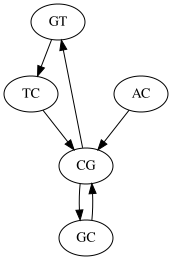

In [37]:
%load_ext gvmagic
%dotstr visualize_de_bruijn("ACGCGTCG", 3)